In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.metrics import (
    accuracy_score ,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer 
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn import set_config


In [2]:
set_config(transform_output='pandas')

## Load Data

In [3]:
df = pd.read_csv("../../data/cleaned_heart_disease.csv")
df.head()

,age,sex,chestpaintype,restingbp,cholesterol,fastingbs,restingecg,max_hr,exercise_angina,old_peak,st_slope,heartdisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.drop(columns=['fastingbs','restingecg','max_hr','old_peak','st_slope'], inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              918 non-null    int64 
 1   sex              918 non-null    object
 2   chestpaintype    918 non-null    object
 3   restingbp        918 non-null    int64 
 4   cholesterol      918 non-null    int64 
 5   exercise_angina  918 non-null    object
 6   heartdisease     918 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 50.3+ KB


## split the data

In [6]:
num_cols = ['age','restingbp','cholesterol']
cat_cols = ['sex','chestpaintype','exercise_angina']


x = df.drop('heartdisease', axis=1)[num_cols+cat_cols]
y = df['heartdisease']

X_train,X_test,Y_train,Y_test =  train_test_split(x,y , stratify=y , random_state= 42, test_size=0.2)

In [7]:
print('X_train: ', X_train.shape)
print('X_test: ', X_test.shape)
print('Y_train: ', Y_train.shape)
print('Y_test: ', Y_test.shape)

X_train:  (734, 6)
X_test:  (184, 6)
Y_train:  (734,)
Y_test:  (184,)


In [8]:
print(Y_test.value_counts(normalize=True))
print(Y_train.value_counts(normalize=True))

heartdisease
1    0.554348
0    0.445652
Name: proportion, dtype: float64
heartdisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64


## Define categorical& num  transformer

In [9]:
num_preprocessor =  make_pipeline(
    SimpleImputer(strategy='median')
)


preprocessor =  ColumnTransformer(
    transformers =[
        ('num', num_preprocessor,num_cols),
       ( 'cat_encoder',OneHotEncoder(sparse_output=False , drop='if_binary'), cat_cols )
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

###  Define Utility functions and Tables

In [10]:
def get_errors(model, X, y):
    """Computes the error metrics for evaluating a classification model."""

    preds = model.predict(X)
    accuracy = accuracy_score(y, preds)
    recall = recall_score(y, preds)
    precision = precision_score(y, preds, zero_division=0.0)
    return {"accuracy": accuracy, "recall": recall, "precision": precision}


def get_avg_cv_errors(cv_result):
    """Get the average value of the error metrics from the cross validation result."""

    return {
        "accuracy": cv_result["test_accuracy"].mean(),
        "recall": cv_result["test_recall"].mean(),
        "precision": cv_result["test_precision"].mean(),
    }


def plot_confusion_matrix(model, model_name, X, y, split="test"):
    """Plot the confusion matrix of a classification model."""

    ConfusionMatrixDisplay.from_estimator(model, X, y)
    plt.title(f"Confusion Matrix of {model_name} Model [{split.title()} Set]")


def log_error(model_name, errors, eval_set, perf_df):
    """Store the performance metrics of a model."""

    cols = [eval_set + "_" + err for err in ("accuracy", "recall", "precision")]
    perf_df.loc[model_name, cols] = list(errors)

In [11]:
perf_df = pd.DataFrame(
    columns=[
        "train_accuracy",
        "train_recall",
        "train_precision",
        "cv_accuracy",
        "cv_recall",
        "cv_precision",
        "test_accuracy",
        "test_recall",
        "test_precision"
    ]
)

perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision


## Build  and Evaluate baseline model 

In [12]:
base_model = DummyClassifier()
base_model.fit(X_train,Y_train)

,strategy,'prior'
,random_state,None
,constant,None


In [13]:
base_train_pred = base_model.predict(X_train)

In [14]:
base_train_pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [15]:
# Evaluate train model

base_train_error = get_errors(base_model,X_train,Y_train)
base_train_error

{'accuracy': 0.553133514986376, 'recall': 1.0, 'precision': 0.553133514986376}

In [16]:
# Log train error
log_error("Base Model", base_train_error.values(), "train", perf_df)

In [17]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,NaN,NaN,NaN,NaN,NaN,NaN


#### Get cross val error 

In [18]:
base_cv_error = cross_validate(base_model, X_train,Y_train, scoring=get_errors, cv=5)
base_cv_error

{'fit_time': array([0.        , 0.00818205, 0.00860095, 0.00150657, 0.00213718]),
 'score_time': array([0.00401258, 0.        , 0.00601816, 0.00627208, 0.00977159]),
 'test_accuracy': array([0.55782313, 0.55102041, 0.55102041, 0.55102041, 0.55479452]),
 'test_recall': array([1., 1., 1., 1., 1.]),
 'test_precision': array([0.55782313, 0.55102041, 0.55102041, 0.55102041, 0.55479452])}

In [19]:
base_avg_cv_error = get_avg_cv_errors(base_cv_error)
base_avg_cv_error

{'accuracy': np.float64(0.5531357748578885),
 'recall': np.float64(1.0),
 'precision': np.float64(0.5531357748578885)}

In [20]:
log_error("Base Model",base_avg_cv_error.values(), "cv" , perf_df)

In [21]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,NaN,NaN,NaN


#### Evalute model on test set 

In [22]:
base_test_pred = base_model.predict(X_test)
base_test_pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [23]:
base_test_error = get_errors(base_model,X_test,Y_test)
base_test_error

{'accuracy': 0.5543478260869565,
 'recall': 1.0,
 'precision': 0.5543478260869565}

In [24]:
log_error('Base Model', base_test_error.values(),"test",perf_df)

In [25]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348


## Base Model Confusion Matrix

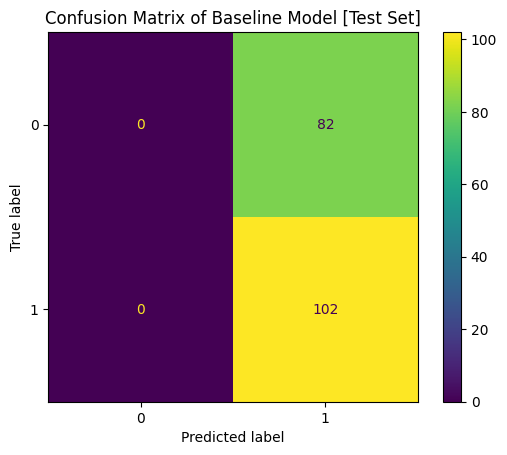

In [26]:
plot_confusion_matrix(base_model,'Baseline',X_test,Y_test)

## Logistics Model

In [27]:
lg_model = LogisticRegression(max_iter=2000)

In [28]:
lg_pipeline = make_pipeline(preprocessor,lg_model)

#### Train model 

In [29]:
lg_pipeline.fit(X_train,Y_train)

,steps,"[('columntransformer', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Evalute mdoel

In [30]:
lg_train_pred = lg_pipeline.predict(X_train)

In [31]:
lg_train_error =  get_errors(lg_pipeline,X_train,Y_train)
lg_train_error

{'accuracy': 0.8010899182561307,
 'recall': 0.8423645320197044,
 'precision': 0.8066037735849056}

#### Get cross validation result

In [32]:
lg_cv_error =  cross_validate(lg_pipeline, X_train,Y_train,cv=5, scoring=get_errors)
lg_cv_error

{'fit_time': array([0.16070366, 0.14469028, 0.09900737, 0.11528492, 0.1855886 ]),
 'score_time': array([0.02164698, 0.01591706, 0.01610398, 0.01186967, 0.02165651]),
 'test_accuracy': array([0.85714286, 0.80952381, 0.80272109, 0.74829932, 0.7260274 ]),
 'test_recall': array([0.87804878, 0.86419753, 0.80246914, 0.80246914, 0.79012346]),
 'test_precision': array([0.86746988, 0.8045977 , 0.83333333, 0.75581395, 0.73563218])}

In [33]:
lg_avg_cv_errors = get_avg_cv_errors(lg_cv_error)
lg_avg_cv_errors

{'accuracy': np.float64(0.7887428944180412),
 'recall': np.float64(0.8274616079494128),
 'precision': np.float64(0.7993694102794497)}

#### Evaluate model on test set 

In [34]:
lg_test_errors = get_errors(lg_pipeline, X_test,Y_test)
lg_test_errors

{'accuracy': 0.8315217391304348,
 'recall': 0.8235294117647058,
 'precision': 0.865979381443299}

#### log errors 

In [35]:
log_error("Lg_Model", lg_train_error.values(),"train", perf_df)
log_error("Lg_Model", lg_avg_cv_errors.values(),"cv", perf_df)
log_error("Lg_Model", lg_test_errors.values(),"test", perf_df)

In [36]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348
Lg_Model,0.80109,0.842365,0.806604,0.788743,0.827462,0.799369,0.831522,0.823529,0.865979


### Lg Model confusion matrix

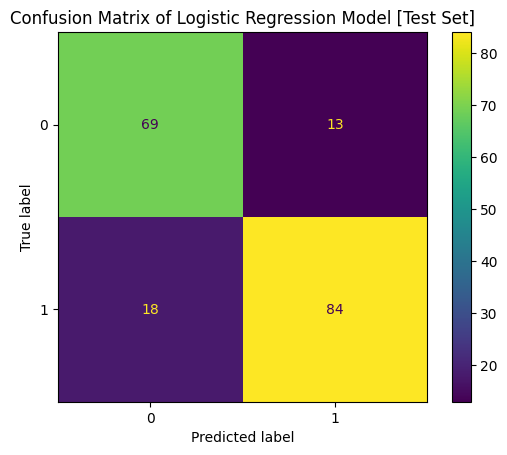

In [37]:
plot_confusion_matrix(lg_pipeline,"Logistic Regression",X_test,Y_test)

### Decision Tree Model 

In [38]:
dt_model = DecisionTreeClassifier(random_state=42)

In [39]:
dt_pipeline = make_pipeline(preprocessor,dt_model)
dt_pipeline.fit(X_train,Y_train)

,steps,"[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Handle overfitting

In [40]:
dt_pipeline[-1].get_depth()

15

In [41]:
param_grid = {"decisiontreeclassifier__max_depth":range(2,15)}

grid_search_cv =  GridSearchCV(
    dt_pipeline, param_grid=param_grid,
    scoring=["accuracy","recall","precision"] ,  refit='recall',
    return_train_score=True
)
grid_search_cv.fit(X_train,Y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'decisiontreeclassifier__max_depth': range(2, 15)}"
,scoring,"['accuracy', 'recall', ...]"
,n_jobs,None
,refit,'recall'
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat_encoder', ...)]"


In [42]:
cv_result = pd.DataFrame(grid_search_cv.cv_results_)
cv_result.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_decisiontreeclassifier__max_depth,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,mean_test_precision,std_test_precision,rank_test_precision,split0_train_precision,split1_train_precision,split2_train_precision,split3_train_precision,split4_train_precision,mean_train_precision,std_train_precision
0,0.030191,0.020557,0.037580,0.020356,2,{'decisiontreeclassifier__max_depth': 2},0.823129,0.782313,0.768707,0.748299,...,0.757602,0.046347,7,0.766017,0.764865,0.763298,0.784703,0.803419,0.776460,0.015566
1,0.045864,0.021413,0.051791,0.011403,3,{'decisiontreeclassifier__max_depth': 3},0.816327,0.802721,0.795918,0.714286,...,0.855348,0.049650,1,0.876923,0.867647,0.853242,0.903846,0.911197,0.882571,0.021849
2,0.030347,0.012756,0.036346,0.010263,4,{'decisiontreeclassifier__max_depth': 4},0.809524,0.829932,0.768707,0.741497,...,0.833516,0.029798,2,0.843137,0.874564,0.864238,0.895683,0.917603,0.879045,0.025660
3,0.010842,0.002202,0.019942,0.008537,5,{'decisiontreeclassifier__max_depth': 5},0.775510,0.775510,0.761905,0.700680,...,0.775422,0.064665,4,0.866242,0.858974,0.886207,0.868339,0.815508,0.859054,0.023543
4,0.011093,0.001907,0.012076,0.003128,6,{'decisiontreeclassifier__max_depth': 6},0.802721,0.775510,0.789116,0.721088,...,0.788691,0.059207,3,0.939716,0.852691,0.880734,0.858726,0.948718,0.896117,0.040468


In [43]:
cv_cols = [
    "param_decisiontreeclassifier__max_depth",
    "mean_test_recall",
    "mean_test_accuracy",
    "mean_test_precision",
    "std_test_recall",
    "mean_train_recall",
    "std_train_recall",
    "rank_test_recall",
    
    "mean_train_accuracy",
    
    "mean_train_precision",
]

In [44]:
cv_results_subset = cv_result[cv_cols].sort_values(["rank_test_recall", "std_test_recall"])

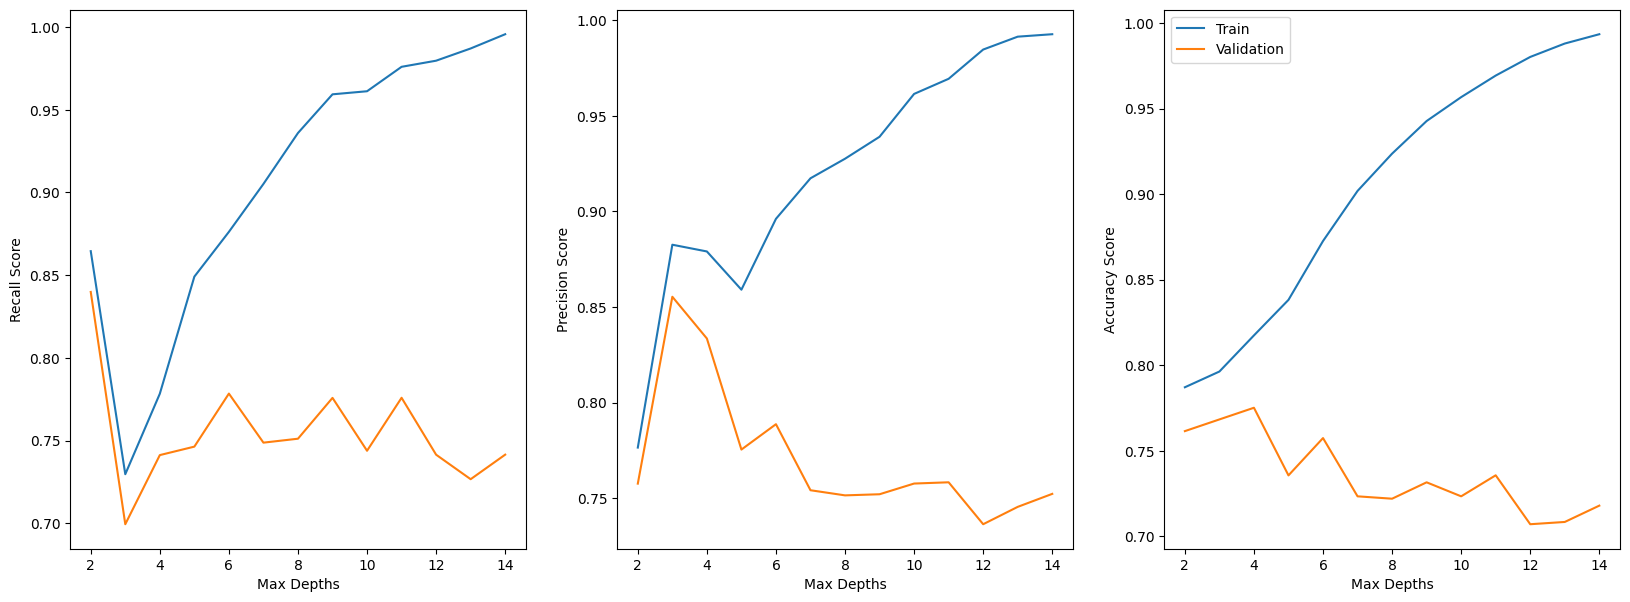

In [45]:
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

ax1.plot(cv_result["param_decisiontreeclassifier__max_depth"], cv_result["mean_train_recall"], label="Train")
ax1.plot(cv_result["param_decisiontreeclassifier__max_depth"], cv_result["mean_test_recall"], label="Validation")
ax1.set_xlabel("Max Depths")
ax1.set_ylabel("Recall Score")

ax2.plot(cv_result["param_decisiontreeclassifier__max_depth"], cv_result["mean_train_precision"], label="Train")
ax2.plot(cv_result["param_decisiontreeclassifier__max_depth"], cv_result["mean_test_precision"], label="Validation")
ax2.set_xlabel("Max Depths")
ax2.set_ylabel("Precision Score")

ax3.plot(cv_result["param_decisiontreeclassifier__max_depth"], cv_result["mean_train_accuracy"], label="Train")
ax3.plot(cv_result["param_decisiontreeclassifier__max_depth"], cv_result["mean_test_accuracy"], label="Validation")
ax3.set_xlabel("Max Depths")
ax3.set_ylabel("Accuracy Score")
plt.legend();

In [46]:
cv_results_subset.set_index("param_decisiontreeclassifier__max_depth").loc[[2,3,4,5,6]]

,mean_test_recall,mean_test_accuracy,mean_test_precision,std_test_recall,mean_train_recall,std_train_recall,rank_test_recall,mean_train_accuracy,mean_train_precision
param_decisiontreeclassifier__max_depth,,,,,,,,,
2,0.839868,0.761476,0.757602,0.041431,0.864522,0.012576,1,0.787118,0.776460
3,0.699428,0.768316,0.855348,0.048305,0.729664,0.021483,13,0.796317,0.882571
4,0.741223,0.775137,0.833516,0.059970,0.778336,0.018543,11,0.817436,0.879045
5,0.746341,0.735598,0.775422,0.040007,0.849132,0.049173,7,0.838212,0.859054
6,0.778410,0.757413,0.788691,0.083096,0.876196,0.060509,2,0.872619,0.896117


 We will choose 4 as the best max depth 

#### Retain the model with max depth of 4

In [47]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)

In [48]:
dt_pipeline = make_pipeline(preprocessor,dt_model)
dt_pipeline.fit(X_train,Y_train)

,steps,"[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Evaluate the training set

In [49]:
dt_train_errors = get_errors(dt_pipeline,X_train,Y_train)
dt_train_errors

{'accuracy': 0.8174386920980926,
 'recall': 0.7980295566502463,
 'precision': 0.8617021276595744}

#### cross validate

In [50]:
dt_cv_errors = cross_validate(dt_pipeline, X_train,Y_train , cv=5 , scoring=get_errors ,  n_jobs=-1)
dt_avg_cv_errors = get_avg_cv_errors(dt_cv_errors)
dt_avg_cv_errors


{'accuracy': np.float64(0.7751374522411705),
 'recall': np.float64(0.7412225233363445),
 'precision': np.float64(0.8335163264177348)}

#### Test set

In [51]:
dt_test_errors = get_errors(dt_pipeline,X_test,Y_test)
dt_test_errors

{'accuracy': 0.8206521739130435,
 'recall': 0.803921568627451,
 'precision': 0.8631578947368421}

In [52]:
log_error("Dt_Model", dt_train_errors.values(), "train", perf_df)
log_error("Dt_Model", dt_avg_cv_errors.values(), "cv", perf_df)
log_error("Dt_Model", dt_test_errors.values(), "test", perf_df)

In [53]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348
Lg_Model,0.80109,0.842365,0.806604,0.788743,0.827462,0.799369,0.831522,0.823529,0.865979
Dt_Model,0.817439,0.79803,0.861702,0.775137,0.741223,0.833516,0.820652,0.803922,0.863158


### confusion matrix for DT

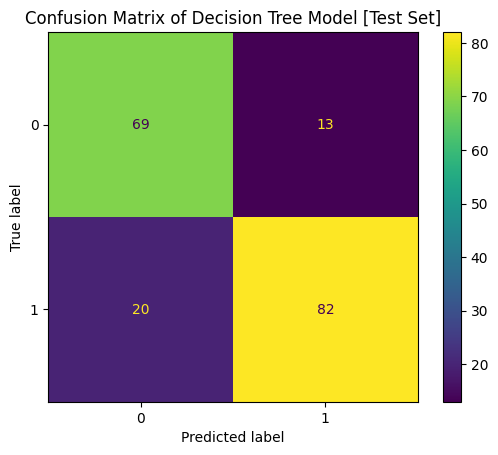

In [129]:
plot_confusion_matrix(dt_pipeline, "Decision Tree", X_test, Y_test)

## Random Forest

In [137]:
rf_model = RandomForestClassifier(max_depth=4 , random_state=42)

In [138]:
rf_pipeline = make_pipeline(preprocessor ,  rf_model)
rf_pipeline.fit(X_train,Y_train)

,steps,"[('columntransformer', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [139]:
rf_train_errors = get_errors(rf_pipeline, X_train, Y_train)
rf_train_errors

{'accuracy': 0.832425068119891,
 'recall': 0.8793103448275862,
 'precision': 0.8283062645011601}

#### Cross validation 

In [140]:
rf_cv_results = cross_validate(rf_pipeline, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5)
rf_avg_cv_errors = get_avg_cv_errors(rf_cv_results)
rf_avg_cv_errors

{'accuracy': np.float64(0.7887615320100643),
 'recall': np.float64(0.8422764227642275),
 'precision': np.float64(0.7910662670787529)}

#### Evaluate on test set 

In [141]:
rf_test_errors = get_errors(rf_pipeline, X_test, Y_test)
rf_test_errors

{'accuracy': 0.8369565217391305,
 'recall': 0.8823529411764706,
 'precision': 0.8333333333333334}

In [142]:
log_error("Rf_Model", rf_train_errors.values(), "train", perf_df)
log_error("Rf_Model", rf_avg_cv_errors.values(), "cv", perf_df)
log_error("Rf_Model", rf_test_errors.values(), "test", perf_df)

In [143]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348
Lg_Model,0.80109,0.842365,0.806604,0.788743,0.827462,0.799369,0.831522,0.823529,0.865979
Dt_Model,0.817439,0.79803,0.861702,0.775137,0.741223,0.833516,0.820652,0.803922,0.863158
Rf_Model,0.832425,0.87931,0.828306,0.788762,0.842276,0.791066,0.836957,0.882353,0.833333
Gb_Model,0.946866,0.960591,0.94431,0.754729,0.763505,0.787664,0.836957,0.843137,0.86
preOpt GB Model,0.865123,0.874384,0.880893,0.779228,0.800391,0.802545,0.836957,0.833333,0.867347
Opt GB+KM Model,0.97139,0.987685,0.961631,0.773805,0.788287,0.801984,0.853261,0.823529,0.903226
Opt GB+KM+TTCV Model,0.97139,0.980296,0.96837,0.768335,0.753809,0.817693,0.853261,0.823529,0.903226


### Plot Rf model Confusion matrix 

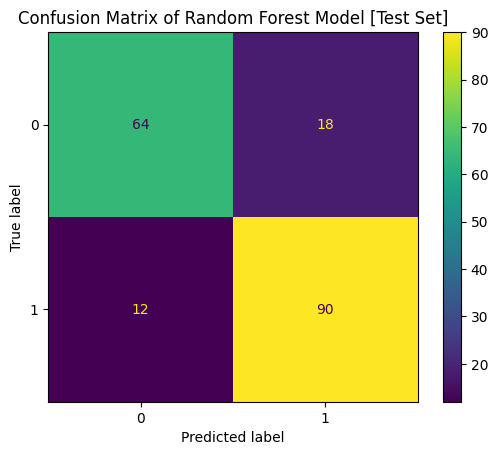

In [144]:
plot_confusion_matrix(rf_pipeline, "Random Forest", X_test, Y_test)

array([0.07972575, 0.03572551, 0.14623641, 0.04981574, 0.2564731 ,
       0.11091825, 0.02488266, 0.00582063, 0.29040195])

## Gradient Boosting 

In [63]:
gb_model = GradientBoostingClassifier(max_depth=4, random_state=42)

In [64]:
gb_pipeline = make_pipeline(preprocessor, gb_model)
gb_pipeline.fit(X_train, Y_train)

,steps,"[('columntransformer', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


### Evaluate Model on trainig set 

In [65]:
gb_train_errors = get_errors(gb_pipeline, X_train, Y_train)
gb_train_errors

{'accuracy': 0.946866485013624,
 'recall': 0.9605911330049262,
 'precision': 0.9443099273607748}

### Cross   Validation

In [66]:
cv_results = cross_validate(gb_pipeline, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5)
gb_avg_cv_errors = get_avg_cv_errors(cv_results)
gb_avg_cv_errors

{'accuracy': np.float64(0.7547292889758644),
 'recall': np.float64(0.7635049683830172),
 'precision': np.float64(0.78766399715709)}

## Test set 

In [67]:
gb_test_errors = get_errors(gb_pipeline, X_test, Y_test)
gb_test_errors

{'accuracy': 0.8369565217391305,
 'recall': 0.8431372549019608,
 'precision': 0.86}

## Log errors 

In [68]:
log_error("Gb_Model", gb_train_errors.values(), "train", perf_df)
log_error("Gb_Model", gb_avg_cv_errors.values(), "cv", perf_df)
log_error("Gb_Model", gb_test_errors.values(), "test", perf_df)

In [69]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348
Lg_Model,0.80109,0.842365,0.806604,0.788743,0.827462,0.799369,0.831522,0.823529,0.865979
Dt_Model,0.817439,0.79803,0.861702,0.775137,0.741223,0.833516,0.820652,0.803922,0.863158
Rf_Model,0.832425,0.87931,0.828306,0.788762,0.842276,0.791066,0.836957,0.882353,0.833333
Gb_Model,0.946866,0.960591,0.94431,0.754729,0.763505,0.787664,0.836957,0.843137,0.86


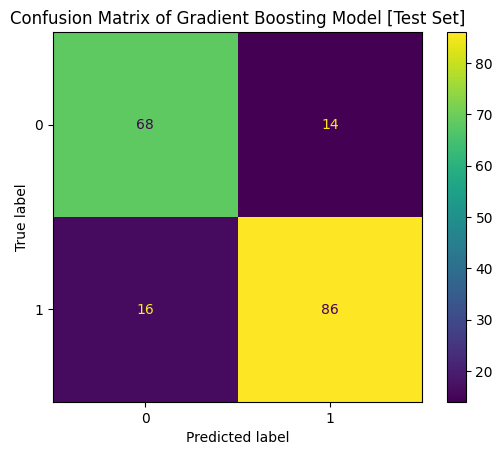

In [70]:
plot_confusion_matrix(gb_pipeline, "Gradient Boosting", X_test, Y_test)

### Find Optimal Learning Rate of Gradient Boosting 

In [71]:
param_grid = {"gradientboostingclassifier__learning_rate": np.linspace(0.01, 0.1, 10), 
              "gradientboostingclassifier__n_estimators":[100,200,300]
              
              }

grid_search_cv = GridSearchCV(
    gb_pipeline,
    param_grid=param_grid,
    scoring=["accuracy", "recall", "precision"],
    return_train_score=True,
    refit="recall",
    n_jobs=-1,
)
grid_search_cv.fit(X_train, Y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'gradientboostingclassifier__learning_rate': array([0.01, ..., 0.09, 0.1 ]), 'gradientboostingclassifier__n_estimators': [100, 200, ...]}"
,scoring,"['accuracy', 'recall', ...]"
,n_jobs,-1
,refit,'recall'
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat_encoder', ...)]"


In [72]:
cv_results = pd.DataFrame(grid_search_cv.cv_results_)

In [73]:
cv_cols = [
    "param_gradientboostingclassifier__learning_rate",
    "param_gradientboostingclassifier__n_estimators",
    "mean_test_recall",
    "mean_test_precision",
    "mean_test_accuracy",
    "rank_test_recall",
    "mean_train_recall",
    
    
    "mean_train_accuracy",
    
    "mean_train_precision",
]
cv_results_subset = cv_results[cv_cols].sort_values(["rank_test_recall"])

In [74]:
cv_results_subset.sort_values("param_gradientboostingclassifier__learning_rate")[:20]

,param_gradientboostingclassifier__learning_rate,param_gradientboostingclassifier__n_estimators,mean_test_recall,mean_test_precision,mean_test_accuracy,rank_test_recall,mean_train_recall,mean_train_accuracy,mean_train_precision
2,0.01,300,0.797952,0.800028,0.776489,2,0.913159,0.893049,0.895499
1,0.01,200,0.797922,0.796368,0.773768,5,0.895924,0.877724,0.884583
0,0.01,100,0.775760,0.789973,0.760134,16,0.853432,0.845707,0.866292
4,0.02,200,0.797892,0.808077,0.781940,6,0.926099,0.908037,0.909342
5,0.02,300,0.788166,0.799819,0.772435,9,0.948887,0.932559,0.930569
3,0.02,100,0.800391,0.802545,0.779228,1,0.894078,0.878405,0.887040
7,0.03,200,0.795544,0.802346,0.776526,7,0.948272,0.931879,0.929979
6,0.03,100,0.797952,0.798151,0.775128,2,0.911312,0.891005,0.893698
8,0.03,300,0.770912,0.794575,0.761541,18,0.968593,0.954356,0.949913
10,0.04,200,0.775821,0.796974,0.765632,13,0.961206,0.945844,0.942073


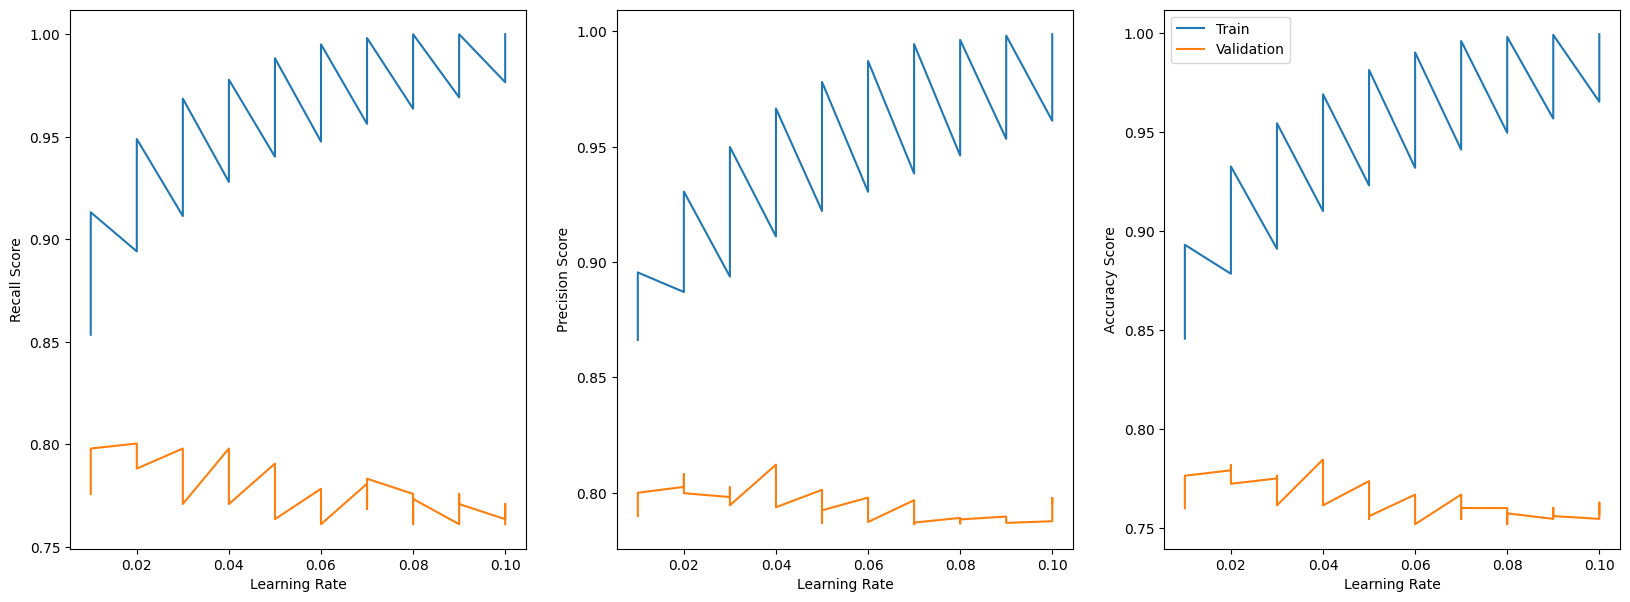

In [75]:
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

ax1.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_recall"], label="Train")
ax1.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_recall"], label="Validation")
ax1.set_xlabel("Learning Rate")
ax1.set_ylabel("Recall Score")

ax2.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_precision"], label="Train")
ax2.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_precision"], label="Validation")
ax2.set_xlabel("Learning Rate")
ax2.set_ylabel("Precision Score")

ax3.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_accuracy"], label="Train")
ax3.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_accuracy"], label="Validation")
ax3.set_xlabel("Learning Rate")
ax3.set_ylabel("Accuracy Score")
plt.legend();

### Retrain model using learning rate of 0.01, min_leaf 3 and n_estimator 100

In [76]:
gb_model_pretrain = GradientBoostingClassifier(max_depth=4, learning_rate=0.02, n_estimators=100,  random_state=42)

In [77]:
gb_pipeline_pretrain = make_pipeline(preprocessor, gb_model_pretrain)
gb_pipeline_pretrain.fit(X_train, Y_train)

,steps,"[('columntransformer', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Evalaute on train set 

In [78]:
gb_pretrain_errors = get_errors(gb_pipeline_pretrain, X_train, Y_train)
gb_pretrain_errors

{'accuracy': 0.8651226158038147,
 'recall': 0.874384236453202,
 'precision': 0.8808933002481389}

#### Cross Validate 

In [79]:
pretrain_cv_results = cross_validate(gb_pipeline_pretrain, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5)
pre_gb_avg_cv_errors = get_avg_cv_errors(pretrain_cv_results)
pre_gb_avg_cv_errors

{'accuracy': np.float64(0.7792284036902433),
 'recall': np.float64(0.8003914483589281),
 'precision': np.float64(0.8025454562762491)}

#### Test set 

In [80]:
pretrain_gb_test_errors = get_errors(gb_pipeline_pretrain, X_test, Y_test)
pretrain_gb_test_errors

{'accuracy': 0.8369565217391305,
 'recall': 0.8333333333333334,
 'precision': 0.8673469387755102}

In [81]:
log_error("preOpt GB Model", gb_pretrain_errors.values(), "train", perf_df)
log_error("preOpt GB Model", pre_gb_avg_cv_errors.values(), "cv", perf_df)
log_error("preOpt GB Model", pretrain_gb_test_errors.values(), "test", perf_df)

In [82]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348
Lg_Model,0.80109,0.842365,0.806604,0.788743,0.827462,0.799369,0.831522,0.823529,0.865979
Dt_Model,0.817439,0.79803,0.861702,0.775137,0.741223,0.833516,0.820652,0.803922,0.863158
Rf_Model,0.832425,0.87931,0.828306,0.788762,0.842276,0.791066,0.836957,0.882353,0.833333
Gb_Model,0.946866,0.960591,0.94431,0.754729,0.763505,0.787664,0.836957,0.843137,0.86
preOpt GB Model,0.865123,0.874384,0.880893,0.779228,0.800391,0.802545,0.836957,0.833333,0.867347


### Add Kmeans features to GBmodel

In [83]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import FeatureUnion

In [84]:
kmean_pipe = make_pipeline(
    preprocessor,
    StandardScaler(),
    KMeans(3, random_state=42)
)

In [85]:
feat_union = FeatureUnion(
    [
    ("base_feat", preprocessor),
    ("kmean_feat", kmean_pipe),
    ],
    verbose_feature_names_out = False

)

In [86]:
gb_kmeans_pipeline = make_pipeline(
    feat_union,
    gb_model
)

In [87]:
gb_kmeans_pipeline.fit(X_train,Y_train)

,steps,"[('featureunion', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformer_list,"[('base_feat', ...), ('kmean_feat', ...)]"
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,missing_values,nan
,strategy,'median'


#### Evaluate on Train set 

In [88]:
gb_km_train_errors = get_errors(gb_kmeans_pipeline, X_train, Y_train)
gb_km_train_errors

{'accuracy': 0.9713896457765667,
 'recall': 0.9876847290640394,
 'precision': 0.9616306954436451}

#### Evaluate on cross validation set 

In [89]:
km_cv_results = cross_validate(gb_kmeans_pipeline, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5, n_jobs=-1)
km_gb_avg_cv_errors = get_avg_cv_errors(km_cv_results)
km_gb_avg_cv_errors

{'accuracy': np.float64(0.773804864411518),
 'recall': np.float64(0.7882866606443841),
 'precision': np.float64(0.8019836719836719)}

#### Evaluate on test set

In [90]:
gb_km_test_errors = get_errors(gb_kmeans_pipeline, X_test, Y_test)
gb_km_test_errors

{'accuracy': 0.8532608695652174,
 'recall': 0.8235294117647058,
 'precision': 0.9032258064516129}

#### Log error 

In [91]:
log_error("Opt GB+KM Model", gb_km_train_errors.values(), "train", perf_df)
log_error("Opt GB+KM Model", km_gb_avg_cv_errors.values(), "cv", perf_df)
log_error("Opt GB+KM Model", gb_km_test_errors.values(), "test", perf_df)

In [92]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348
Lg_Model,0.80109,0.842365,0.806604,0.788743,0.827462,0.799369,0.831522,0.823529,0.865979
Dt_Model,0.817439,0.79803,0.861702,0.775137,0.741223,0.833516,0.820652,0.803922,0.863158
Rf_Model,0.832425,0.87931,0.828306,0.788762,0.842276,0.791066,0.836957,0.882353,0.833333
Gb_Model,0.946866,0.960591,0.94431,0.754729,0.763505,0.787664,0.836957,0.843137,0.86
preOpt GB Model,0.865123,0.874384,0.880893,0.779228,0.800391,0.802545,0.836957,0.833333,0.867347
Opt GB+KM Model,0.97139,0.987685,0.961631,0.773805,0.788287,0.801984,0.853261,0.823529,0.903226


### confusion matrix 

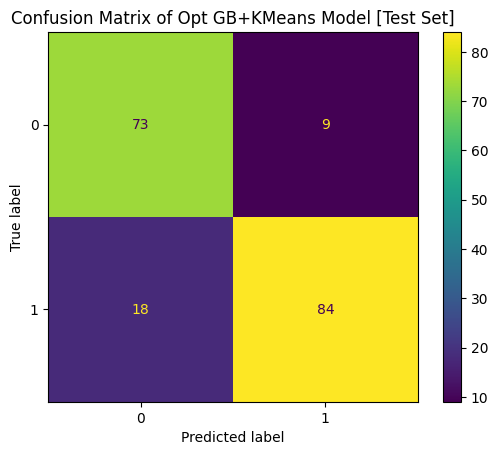

In [93]:
plot_confusion_matrix(gb_kmeans_pipeline, "Opt GB+KMeans", X_test, Y_test)

### Visualize Feature importance

In [94]:
feat_imps = pd.Series(
    gb_kmeans_pipeline[-1].feature_importances_,
    index=gb_kmeans_pipeline[-1].feature_names_in_,
).sort_values()

In [95]:
def clean_feats_name(feature):
    if "__" in feature:
        return feature[feature.index("__")+2:]
    return feature

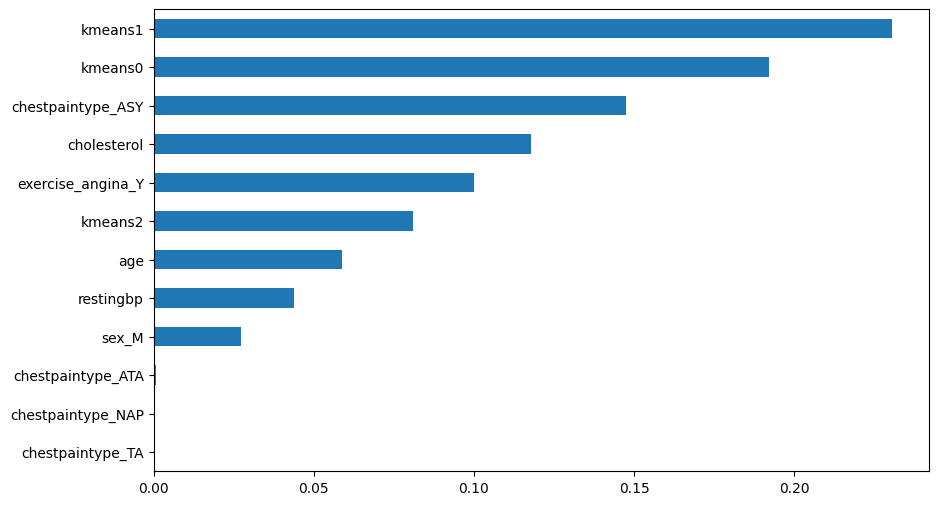

In [96]:
ax = feat_imps.plot(kind="barh", figsize=(10, 6))
ax.set_yticklabels(feat_imps.index.map(clean_feats_name));

#### Handle Class imbalance 

In [97]:
from sklearn.metrics import precision_recall_curve

In [98]:
precision, recall, thresholds = precision_recall_curve(Y_test, gb_kmeans_pipeline.predict_proba(X_test)[:, 1])

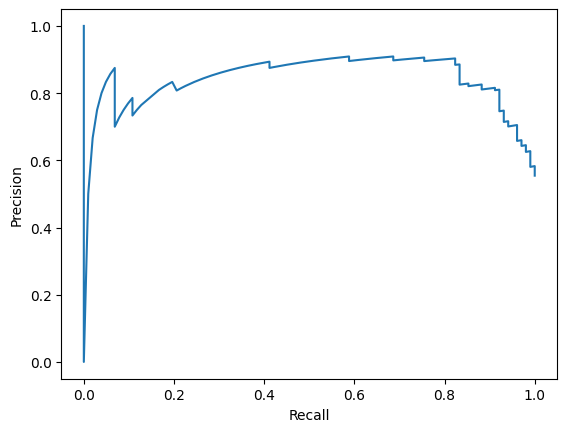

In [99]:
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision");

## Find optimal probality threshold

In [100]:
from sklearn.model_selection import TunedThresholdClassifierCV

In [101]:
ttcv = TunedThresholdClassifierCV(gb_kmeans_pipeline, cv=5, n_jobs=-1)
ttcv.fit(X_train, Y_train)

,estimator,Pipeline(step...m_state=42))])
,scoring,'balanced_accuracy'
,response_method,'auto'
,thresholds,100
,cv,5
,refit,True
,n_jobs,-1
,random_state,None
,store_cv_results,False
,transformer_list,"[('base_feat', ...), ('kmean_feat', ...)]"
,n_jobs,None


### Get the error 

In [102]:
ttcv_train_error = get_errors(ttcv,X_train,Y_train)
ttcv_train_error

{'accuracy': 0.9713896457765667,
 'recall': 0.9802955665024631,
 'precision': 0.9683698296836983}

#### Evaluate with cross validation

In [103]:
ttcv_results = cross_validate(
    ttcv, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5, n_jobs=-1
)


In [104]:
ttcv_cv_errors = get_avg_cv_errors(ttcv_results)
ttcv_cv_errors

{'accuracy': np.float64(0.7683347311527351),
 'recall': np.float64(0.753809093646492),
 'precision': np.float64(0.8176933246135117)}

#### test set 

In [105]:
ttcv_test_error = get_errors(ttcv, X_test, Y_test)
ttcv_test_error

{'accuracy': 0.8532608695652174,
 'recall': 0.8235294117647058,
 'precision': 0.9032258064516129}

#### Plot confusion matrix 

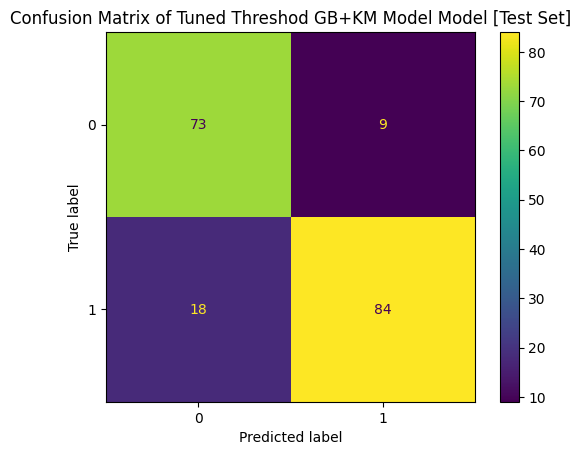

In [106]:
plot_confusion_matrix(
    ttcv, "Tuned Threshod GB+KM Model", X_test, Y_test
)

In [107]:
log_error("Opt GB+KM+TTCV Model", ttcv_train_error.values(), "train", perf_df)
log_error("Opt GB+KM+TTCV Model", ttcv_cv_errors.values(), "cv", perf_df)
log_error("Opt GB+KM+TTCV Model", ttcv_test_error.values(), "test", perf_df)

In [108]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348
Lg_Model,0.80109,0.842365,0.806604,0.788743,0.827462,0.799369,0.831522,0.823529,0.865979
Dt_Model,0.817439,0.79803,0.861702,0.775137,0.741223,0.833516,0.820652,0.803922,0.863158
Rf_Model,0.832425,0.87931,0.828306,0.788762,0.842276,0.791066,0.836957,0.882353,0.833333
Gb_Model,0.946866,0.960591,0.94431,0.754729,0.763505,0.787664,0.836957,0.843137,0.86
preOpt GB Model,0.865123,0.874384,0.880893,0.779228,0.800391,0.802545,0.836957,0.833333,0.867347
Opt GB+KM Model,0.97139,0.987685,0.961631,0.773805,0.788287,0.801984,0.853261,0.823529,0.903226
Opt GB+KM+TTCV Model,0.97139,0.980296,0.96837,0.768335,0.753809,0.817693,0.853261,0.823529,0.903226


### Retrain the whole dataset 

rf demonstrated more stable and consistent perfomance across training , cross validation and test sets , making it the most suitable final model

In [109]:
rf_pipeline.fit(x, y)

,steps,"[('columntransformer', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [110]:
get_errors(rf_pipeline, x, y)

{'accuracy': 0.8387799564270153,
 'recall': 0.8799212598425197,
 'precision': 0.8370786516853933}

## Save Model

In [117]:
import joblib

In [120]:
joblib.dump(rf_pipeline,"../../models/heart_basic_model_v1.pk1")

['../../models/heart_basic_model_v1.pk1']

#### Load Model

In [121]:
model = joblib.load("../../models/heart_basic_model_v1.pk1")

In [122]:
get_errors(model,x,y)

{'accuracy': 0.8387799564270153,
 'recall': 0.8799212598425197,
 'precision': 0.8370786516853933}

In [146]:
df.iloc[50:60]

,age,sex,chestpaintype,restingbp,cholesterol,exercise_angina,heartdisease
50,50,M,ASY,130,233,Y,1
51,47,F,ASY,120,205,Y,1
52,45,M,ATA,140,224,N,0
53,41,F,ATA,130,245,N,0
54,52,F,ASY,130,180,Y,0
55,51,F,ATA,160,194,N,0
56,31,M,ASY,120,270,Y,1
57,58,M,NAP,130,213,N,1
58,54,M,ASY,150,365,N,0
59,52,M,ASY,112,342,Y,1


In [147]:
pd.DataFrame(model.predict(x.iloc[50:60]))

,0
0,1
1,1
2,0
3,0
4,1
5,0
6,1
7,0
8,1
9,1


In [154]:
# x_sample = x.iloc[50:60].copy()
# x_sample['cholesterol'] = np.nan
# model.predict(x_sample)

In [155]:
# pre1 = model.predict(X_test)

# x_mode = X_test.copy()
# x_mode["cholesterol"] =np.nan

# pre2 = model.predict(x_mode)

# diff = (pre1 != pre2).sum()
# print("change pre: ", diff)


# com = pd.DataFrame({
#     "ori" : pre1,
#     "modi": pre2,
#     "act" : Y_test
# })

# com[com['ori'] != com['modi']]